## Simple Processing

An example to proessing images without a proper pipeline

In [1]:
%load_ext autoreload
%autoreload 2
from paidiverpy.open_layer import OpenLayer
from paidiverpy.sampling_layer import SamplingLayer

### Open the images

The first step will be always the load images step

In [2]:
# Instantiate the class
open_layer = OpenLayer(config_file_path="./config_simple.yml")

☁ paidiverpy ☁  |    WARNING | 2025-08-18 15:35:48 | Metadata does not have a camera-position type column. It should have one of the following columns: ['camera-position', 'camera_position', 'altitude_m', 'altitude_metre', 'altitude_meters', 'altitude_meter', 'image-altitude-meters']. 

☁ paidiverpy ☁  |    WARNING | 2025-08-18 15:35:48 | Metadata does not have a depth type column. It should have one of the following columns: ['depth', 'depth_m', 'depth_metres', 'depth_metre', 'depth_meters', 'depth_meter', 'image-depth']. 

☁ paidiverpy ☁  |    WARNING | 2025-08-18 15:35:48 | Metadata does not have a lat type column. It should have one of the following columns: ['lat', 'latitude_deg', 'latitude', 'Latitude', 'Latitude_deg', 'Lat', 'image-latitude']. 

☁ paidiverpy ☁  |    WARNING | 2025-08-18 15:35:48 | Metadata does not have a lon type column. It should have one of the following columns: ['lon', 'longitude_deg', 'longitude', 'Longitude', 'Longitude_deg', 'Lon', 'image-longitude']. 



In [3]:
# See the configuration file
# open_layer.config

In [4]:
# open_layer.metadata.metadata

In [5]:
# Run the open layer process. It will open the images from the input path, and save then as a ImagesLayer
open_layer.run()

[########################################] | 100% Completed | 102.48 ms


/home/tobfer/.pyenv/versions/3.10.12/envs/paidiverpy/lib/python3.10/site-packages/numpy/lib/function_base.py:2506: RuntimeWarning: invalid value encountered in cast
  output[index] = result


In [32]:
open_layer.images.images

<xarray.Dataset> Size: 658kB
Dimensions:          (filename: 10, y_0: 128, x_0: 128, band_0: 4)
Coordinates:
  * filename         (filename) <U20 800B '20180611041421.png' ... '201806110...
  * y_0              (y_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * x_0              (x_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * band_0           (band_0) int64 32B 0 1 2 3
    original_height  (filename) int64 80B 128 128 128 128 128 128 128 128 58 126
    original_width   (filename) int64 80B 128 128 128 128 ... 128 128 102 119
    metadata         (filename) object 80B {'filename': '20180611041421.png',...
Data variables:
    image_0          (filename, y_0, x_0, band_0) uint8 655kB 99 120 69 ... 0 0
Attributes:
    description:  Padded image dataset with masks for valid pixels

In [9]:
coord_names = [
    name for name, da in dataset.images.coords.items()
    if "filename" in da.dims and name != "filename"
]
coord_names

['original_height',
 'original_width',
 'ID',
 'XResolution',
 'YResolution',
 'ExposureTime',
 'FNumber',
 'ISO',
 'image-datetime',
 'MaxApertureValue',
 'WhiteBalance',
 'FocusPosition',
 'FocusDistance',
 'flag']

In [11]:
metadata_list = [
    {name: dataset.images.coords[name].sel(filename=fn).item()
     for name in coord_names}
    for fn in dataset.images["filename"].values
]
metadata_list

[{'original_height': 128,
  'original_width': 128,
  'ID': 430.0,
  'XResolution': 300.0,
  'YResolution': 300.0,
  'ExposureTime': 0.01666666667,
  'FNumber': 8.0,
  'ISO': 200.0,
  'image-datetime': 1528690461000000000,
  'MaxApertureValue': 2.82842712474619,
  'WhiteBalance': 'FLASH       ',
  'FocusPosition': 17.0,
  'FocusDistance': 0.298538261891796,
  'flag': 0},
 {'original_height': 128,
  'original_width': 128,
  'ID': 431.0,
  'XResolution': 300.0,
  'YResolution': 300.0,
  'ExposureTime': 0.01666666667,
  'FNumber': 8.0,
  'ISO': 200.0,
  'image-datetime': 1528690471000000000,
  'MaxApertureValue': 2.82842712474619,
  'WhiteBalance': 'FLASH       ',
  'FocusPosition': 17.0,
  'FocusDistance': 0.298538261891796,
  'flag': 0},
 {'original_height': 128,
  'original_width': 128,
  'ID': 432.0,
  'XResolution': 300.0,
  'YResolution': 300.0,
  'ExposureTime': 0.01666666667,
  'FNumber': 8.0,
  'ISO': 200.0,
  'image-datetime': 1528690481000000000,
  'MaxApertureValue': 2.82842712

In [7]:
dataset.images

<xarray.Dataset> Size: 823kB
Dimensions:           (filename: 10, y_0: 128, x_0: 128, band_0: 4)
Coordinates: (12/18)
  * filename          (filename) <U20 800B '20180611041421.png' ... '20180611...
  * y_0               (y_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * x_0               (x_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * band_0            (band_0) int64 32B 0 1 2 3
    original_height   (filename) int64 80B 128 128 128 128 ... 128 128 58 126
    original_width    (filename) int64 80B 128 128 128 128 ... 128 128 102 119
    ...                ...
    image-datetime    (filename) datetime64[ns] 80B 2018-06-11T04:14:21 ... 2...
    MaxApertureValue  (filename) float64 80B 2.828 2.828 2.828 ... 2.828 2.828
    WhiteBalance      (filename) object 80B 'FLASH       ' ... 'FLASH       '
    FocusPosition     (filename) float64 80B 17.0 17.0 17.0 ... 17.0 17.0 17.0
    FocusDistance     (filename) float64 80B 0.2985 0.2985 ... 0.2985 0.2985
    flag              (filename) int64 80B 0 0 0 0 0 0 0 0 0 0
Data variables:
    image_0           (filename, y_0, x_0, band_0) uint8 655kB 179 189 ... 0 0
    mask_0            (filename, y_0, x_0) bool 164kB True True ... False False
Attributes:
    description:  Padded image dataset with masks for valid pixels

In [87]:
"ID" in open_layer.images.images

True

In [101]:
import pandas as pd
x = [{"filename": 1}, {"filename": 2}]
len(pd.DataFrame(x).set_index("filename").columns)

0

In [103]:
if pd.DataFrame(x).set_index("filename").columns:
    print("ok")

ValueError: The truth value of a Index is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [96]:
open_layer.images.images[["ID","XResolution"]].to_dataframe()

,ID,XResolution,original_height,original_width,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,FocusPosition,FocusDistance,flag
filename,,,,,,,,,,,,,,
20180611041421.png,430.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:14:21,2.828427,FLASH,17.0,0.298538,0
20180611041431.png,431.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:14:31,2.828427,FLASH,17.0,0.298538,0
20180611041441.png,432.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:14:41,2.828427,FLASH,17.0,0.298538,0
20180611041451.png,433.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:14:51,2.828427,FLASH,17.0,0.298538,0
20180611041501.png,434.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:15:01,2.828427,FLASH,17.0,0.298538,0
20180611041511.png,435.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:15:11,2.828427,FLASH,17.0,0.298538,0
20180611041521.png,436.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:15:21,2.828427,FLASH,17.0,0.298538,0
20180611041531.png,437.0,300.0,128,128,300.0,0.016667,8.0,200.0,2018-06-11 04:15:31,2.828427,FLASH,17.0,0.298538,0
20180611041921_2.png,438.0,300.0,58,102,300.0,0.016667,8.0,200.0,2018-06-11 04:15:41,2.828427,FLASH,17.0,0.298538,0


In [92]:
open_layer.images.images

<xarray.Dataset> Size: 823kB
Dimensions:           (filename: 10, y_0: 128, x_0: 128, band_0: 4)
Coordinates: (12/18)
  * filename          (filename) <U20 800B '20180611041421.png' ... '20180611...
  * y_0               (y_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * x_0               (x_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * band_0            (band_0) int64 32B 0 1 2 3
    original_height   (filename) int64 80B 128 128 128 128 ... 128 128 58 126
    original_width    (filename) int64 80B 128 128 128 128 ... 128 128 102 119
    ...                ...
    image-datetime    (filename) datetime64[ns] 80B 2018-06-11T04:14:21 ... 2...
    MaxApertureValue  (filename) float64 80B 2.828 2.828 2.828 ... 2.828 2.828
    WhiteBalance      (filename) object 80B 'FLASH       ' ... 'FLASH       '
    FocusPosition     (filename) float64 80B 17.0 17.0 17.0 ... 17.0 17.0 17.0
    FocusDistance     (filename) float64 80B 0.2985 0.2985 ... 0.2985 0.2985
    flag              (filename) int64 80B 0 0 0 0 0 0 0 0 0 0
Data variables:
    image_0           (filename, y_0, x_0, band_0) uint8 655kB 179 189 ... 0 0
    mask_0            (filename, y_0, x_0) bool 164kB True True ... False False
Attributes:
    description:  Padded image dataset with masks for valid pixels

In [76]:
open_layer.images

KeyError: "'step' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'filename': 10, 'y_0': 128, 'x_0': 128, 'band_0': 4})"

Step: raw
Image: i
Image: m
Image: a
Image: g
Image: e
Image: _
Image: 0

In [22]:
import numpy as np
import xarray as xr
def convert_to_variable_shape(ds: xr.Dataset) -> xr.Dataset:
    """
    Convert a fixed-size padded image dataset into a variable-shape object-based dataset.
    Uses `original_height` and `original_width` to crop images and masks.

    Parameters
    ----------
    ds : xr.Dataset
        Original dataset with fixed-size padded images.
        Must have:
            - data_vars: 'image' (step, filename, y, x, band), 'mask' (step, filename, y, x)
            - coords: 'original_height' (filename), 'original_width' (filename)

    Returns
    -------
    xr.Dataset
        Dataset with:
            - image (step, filename) object array of numpy arrays
            - mask (step, filename) object array of numpy arrays
            - height, width, bands metadata arrays
    """
    steps = ds.step.values
    filenames = ds.filename.values
    
    images_obj = np.empty((len(steps), len(filenames)), dtype=object)
    masks_obj = np.empty((len(steps), len(filenames)), dtype=object)
    height_arr = np.empty((len(steps), len(filenames)), dtype=int)
    width_arr = np.empty((len(steps), len(filenames)), dtype=int)
    bands_arr = np.empty((len(steps), len(filenames)), dtype=int)

    for si, step in enumerate(steps):
        for fi, fname in enumerate(filenames):
            h = int(ds.original_height.sel(filename=fname).item())
            w = int(ds.original_width.sel(filename=fname).item())

            # Crop padded image to original size
            img = ds.image.sel(step=step, filename=fname).values[:h, :w, :]
            mask = ds.mask.sel(step=step, filename=fname).values[:h, :w]

            # Store in object arrays
            images_obj[si, fi] = img
            masks_obj[si, fi] = mask
            height_arr[si, fi] = h
            width_arr[si, fi] = w
            bands_arr[si, fi] = img.shape[2] if img.ndim == 3 else 1

    # Build new dataset
    ds_varshape = xr.Dataset(
        data_vars=dict(
            image=(("step", "filename"), images_obj),
            mask=(("step", "filename"), masks_obj),
            height=(("step", "filename"), height_arr),
            width=(("step", "filename"), width_arr),
            bands=(("step", "filename"), bands_arr),
        ),
        coords=dict(
            step=steps,
            filename=filenames,
        ),
        attrs=dict(description="Variable-shape images with per-step metadata")
    )

    return ds_varshape


In [24]:
ds_varshape = convert_to_variable_shape(open_layer.images.images)

In [50]:
ds_varshape.image.isel({"step":0, "filename": 1}).item().shape

(128, 128, 4)


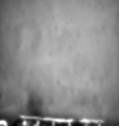

In [57]:
open_layer.images.show(-1)

Step: raw
Image: i
Image: m
Image: a
Image: g
Image: e
Image: _
Image: 0
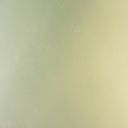
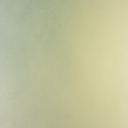
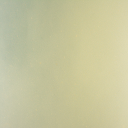
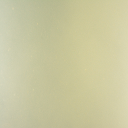
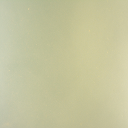
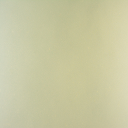
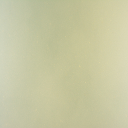
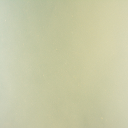
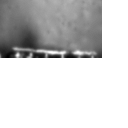
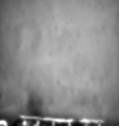

In [77]:
open_layer.images

In [29]:
dataset.filename.to_numpy()

array(['20180611041421.png', '20180611041431.png', '20180611041441.png',
       '20180611041451.png', '20180611041501.png', '20180611041511.png',
       '20180611041521.png', '20180611041531.png', '20180611041921_2.png',
       '20180611041941_2.png'], dtype='<U20')

In [13]:
open_layer.metadata

,ID,image-filename,flag
0,0,20180611041421.png,0
1,1,20180611041431.png,0
2,2,20180611041441.png,0
3,3,20180611041451.png,0
4,4,20180611041501.png,0
5,5,20180611041511.png,0
6,6,20180611041521.png,0
7,7,20180611041531.png,0
8,8,20180611041921_2.png,0
9,9,20180611041941_2.png,0


Step: raw
Image: [[[178]
  [177]
  [176]
  ...
  [174]
  [174]
  [175]]

 [[176]
  [175]
  [175]
  ...
  [174]
  [174]
  [180]]

 [[175]
  [176]
  [174]
  ...
  [176]
  [179]
  [176]]

 ...

 [[185]
  [185]
  [185]
  ...
  [204]
  [202]
  [203]]

 [[184]
  [186]
  [185]
  ...
  [201]
  [202]
  [203]]

 [[183]
  [185]
  [185]
  ...
  [202]
  [203]
  [203]]]
Image: [[[161]
  [161]
  [160]
  ...
  [167]
  [166]
  [166]]

 [[162]
  [160]
  [157]
  ...
  [168]
  [167]
  [166]]

 [[162]
  [162]
  [162]
  ...
  [164]
  [168]
  [168]]

 ...

 [[126]
  [122]
  [150]
  ...
  [157]
  [156]
  [156]]

 [[123]
  [127]
  [156]
  ...
  [157]
  [156]
  [154]]

 [[123]
  [148]
  [150]
  ...
  [159]
  [155]
  [155]]]
Image: [[[108]
  [107]
  [113]
  ...
  [161]
  [159]
  [159]]

 [[109]
  [112]
  [110]
  ...
  [161]
  [160]
  [162]]

 [[112]
  [113]
  [115]
  ...
  [163]
  [162]
  [159]]

 ...

 [[161]
  [161]
  [169]
  ...
  [125]
  [125]
  [127]]

 [[162]
  [164]
  [171]
  ...
  [132]
  [126]
  [127]]

 [[160]
  [168]
  [172]
  ...
  [129]
  [127]
  [128]]]
Image: [[[ 56]
  [ 58]
  [ 61]
  ...
  [ 63]
  [ 62]
  [ 62]]

 [[ 59]
  [ 61]
  [ 58]
  ...
  [ 62]
  [ 63]
  [ 61]]

 [[ 53]
  [ 61]
  [ 62]
  ...
  [ 62]
  [ 65]
  [ 63]]

 ...

 [[108]
  [105]
  [142]
  ...
  [ 96]
  [ 96]
  [ 93]]

 [[106]
  [114]
  [146]
  ...
  [ 95]
  [ 92]
  [ 90]]

 [[106]
  [141]
  [143]
  ...
  [ 91]
  [ 95]
  [ 94]]]
Image: [[[ 41]
  [ 40]
  [ 42]
  ...
  [ 46]
  [ 45]
  [ 44]]

 [[ 40]
  [ 41]
  [ 40]
  ...
  [ 46]
  [ 49]
  [ 46]]

 [[ 40]
  [ 42]
  [ 41]
  ...
  [ 50]
  [ 47]
  [ 47]]

 ...

 [[ 26]
  [ 25]
  [114]
  ...
  [ 35]
  [ 34]
  [ 34]]

 [[ 28]
  [ 40]
  [137]
  ...
  [ 33]
  [ 35]
  [ 33]]

 [[ 22]
  [134]
  [142]
  ...
  [ 34]
  [ 35]
  [ 33]]]
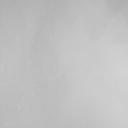
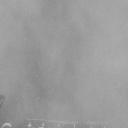
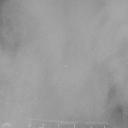
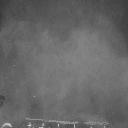
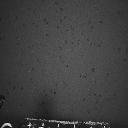

In [5]:
d# See the images output
open_layer.images

In [6]:
open_layer.get_metadata()

,image-filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,temperature_c,positioning_ok,attitude_ok,depth_ok,altitude_ok,X,phototime,flag,point,num_channels
0,20180611T041631.000Z.PNG,443.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:31,2.828427,FLASH,...,1.4456,1,1,1,1,NaN,2018-06-11 04:16:31,0,POINT (-153.60532064 11.2516466),1
1,20180611T041721.000Z.PNG,448.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:21,2.828427,FLASH,...,1.4537,1,1,1,1,NaN,2018-06-11 04:17:21,0,POINT (-153.60532022 11.25162976),1
2,20180611T041801.000Z.PNG,452.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:01,2.828427,FLASH,...,1.4460,1,1,1,1,NaN,2018-06-11 04:18:01,0,POINT (-153.60530782 11.25162813),1
3,20180611T041901.000Z.PNG,458.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:19:01,2.828427,FLASH,...,1.4435,1,1,1,1,NaN,2018-06-11 04:19:01,0,POINT (-153.60526246 11.25164123),1
4,20180611T042111.000Z.PNG,471.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:21:11,2.828427,FLASH,...,1.4315,1,1,1,1,NaN,2018-06-11 04:21:11,0,POINT (-153.60516435 11.2516341),1



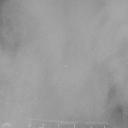

In [8]:
# See a particular image
open_layer.images.show(image_number=2)

In [9]:
# See the first 5 lines of the metadata
open_layer.get_metadata().head(5)

,image-filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,temperature_c,positioning_ok,attitude_ok,depth_ok,altitude_ok,X,phototime,flag,point,num_channels
0,20180611T041631.000Z.PNG,443.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:31,2.828427,FLASH,...,1.4456,1,1,1,1,NaN,2018-06-11 04:16:31,0,POINT (-153.60532064 11.2516466),1
1,20180611T041721.000Z.PNG,448.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:21,2.828427,FLASH,...,1.4537,1,1,1,1,NaN,2018-06-11 04:17:21,0,POINT (-153.60532022 11.25162976),1
2,20180611T041801.000Z.PNG,452.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:01,2.828427,FLASH,...,1.4460,1,1,1,1,NaN,2018-06-11 04:18:01,0,POINT (-153.60530782 11.25162813),1
3,20180611T041901.000Z.PNG,458.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:19:01,2.828427,FLASH,...,1.4435,1,1,1,1,NaN,2018-06-11 04:19:01,0,POINT (-153.60526246 11.25164123),1
4,20180611T042111.000Z.PNG,471.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:21:11,2.828427,FLASH,...,1.4315,1,1,1,1,NaN,2018-06-11 04:21:11,0,POINT (-153.60516435 11.2516341),1


### Resample the images

The add a next step to your processing pipeline, you need to instantiate the SamplingLayer class and pass the OpenLayer class as an argument

In [10]:
# Set the parameters
parameters = {
    "name": "datetime",
    "mode": "datetime",
    "params": {"min": "2018-06-11 04:14:00", "max": "2018-06-11 04:20:00"},
}

In [11]:
# Instantiate the new class
resample = SamplingLayer(paidiverpy=open_layer, parameters=parameters)

In [12]:
# Run the process using the parameters provided
resample.run()

☁ paidiverpy ☁  |       INFO | 2025-06-03 15:30:00 | Number of images to be removed: 1. Total number of images: 5


INFO:paidiverpy:Number of images to be removed: 1. Total number of images: 5


Step: raw
Image: [[[178]
  [177]
  [176]
  ...
  [174]
  [174]
  [175]]

 [[176]
  [175]
  [175]
  ...
  [174]
  [174]
  [180]]

 [[175]
  [176]
  [174]
  ...
  [176]
  [179]
  [176]]

 ...

 [[185]
  [185]
  [185]
  ...
  [204]
  [202]
  [203]]

 [[184]
  [186]
  [185]
  ...
  [201]
  [202]
  [203]]

 [[183]
  [185]
  [185]
  ...
  [202]
  [203]
  [203]]]
Image: [[[161]
  [161]
  [160]
  ...
  [167]
  [166]
  [166]]

 [[162]
  [160]
  [157]
  ...
  [168]
  [167]
  [166]]

 [[162]
  [162]
  [162]
  ...
  [164]
  [168]
  [168]]

 ...

 [[126]
  [122]
  [150]
  ...
  [157]
  [156]
  [156]]

 [[123]
  [127]
  [156]
  ...
  [157]
  [156]
  [154]]

 [[123]
  [148]
  [150]
  ...
  [159]
  [155]
  [155]]]
Image: [[[108]
  [107]
  [113]
  ...
  [161]
  [159]
  [159]]

 [[109]
  [112]
  [110]
  ...
  [161]
  [160]
  [162]]

 [[112]
  [113]
  [115]
  ...
  [163]
  [162]
  [159]]

 ...

 [[161]
  [161]
  [169]
  ...
  [125]
  [125]
  [127]]

 [[162]
  [164]
  [171]
  ...
  [132]
  [126]
  [127]]

 [[160]
  [168]
  [172]
  ...
  [129]
  [127]
  [128]]]
Image: [[[ 56]
  [ 58]
  [ 61]
  ...
  [ 63]
  [ 62]
  [ 62]]

 [[ 59]
  [ 61]
  [ 58]
  ...
  [ 62]
  [ 63]
  [ 61]]

 [[ 53]
  [ 61]
  [ 62]
  ...
  [ 62]
  [ 65]
  [ 63]]

 ...

 [[108]
  [105]
  [142]
  ...
  [ 96]
  [ 96]
  [ 93]]

 [[106]
  [114]
  [146]
  ...
  [ 95]
  [ 92]
  [ 90]]

 [[106]
  [141]
  [143]
  ...
  [ 91]
  [ 95]
  [ 94]]]
Image: [[[ 41]
  [ 40]
  [ 42]
  ...
  [ 46]
  [ 45]
  [ 44]]

 [[ 40]
  [ 41]
  [ 40]
  ...
  [ 46]
  [ 49]
  [ 46]]

 [[ 40]
  [ 42]
  [ 41]
  ...
  [ 50]
  [ 47]
  [ 47]]

 ...

 [[ 26]
  [ 25]
  [114]
  ...
  [ 35]
  [ 34]
  [ 34]]

 [[ 28]
  [ 40]
  [137]
  ...
  [ 33]
  [ 35]
  [ 33]]

 [[ 22]
  [134]
  [142]
  ...
  [ 34]
  [ 35]
  [ 33]]]
Step: sampling
Image: [[[178]
  [177]
  [176]
  ...
  [174]
  [174]
  [175]]

 [[176]
  [175]
  [175]
  ...
  [174]
  [174]
  [180]]

 [[175]
  [176]
  [174]
  ...
  [176]
  [179]
  [176]]

 ...

 [[185]
  [185]
  [185]
  ...
  [204]
  [202]
  [203]]

 [[184]
  [186]
  [185]
  ...
  [201]
  [202]
  [203]]

 [[183]
  [185]
  [185]
  ...
  [202]
  [203]
  [203]]]
Image: [[[161]
  [161]
  [160]
  ...
  [167]
  [166]
  [166]]

 [[162]
  [160]
  [157]
  ...
  [168]
  [167]
  [166]]

 [[162]
  [162]
  [162]
  ...
  [164]
  [168]
  [168]]

 ...

 [[126]
  [122]
  [150]
  ...
  [157]
  [156]
  [156]]

 [[123]
  [127]
  [156]
  ...
  [157]
  [156]
  [154]]

 [[123]
  [148]
  [150]
  ...
  [159]
  [155]
  [155]]]
Image: [[[108]
  [107]
  [113]
  ...
  [161]
  [159]
  [159]]

 [[109]
  [112]
  [110]
  ...
  [161]
  [160]
  [162]]

 [[112]
  [113]
  [115]
  ...
  [163]
  [162]
  [159]]

 ...

 [[161]
  [161]
  [169]
  ...
  [125]
  [125]
  [127]]

 [[162]
  [164]
  [171]
  ...
  [132]
  [126]
  [127]]

 [[160]
  [168]
  [172]
  ...
  [129]
  [127]
  [128]]]
Image: [[[ 56]
  [ 58]
  [ 61]
  ...
  [ 63]
  [ 62]
  [ 62]]

 [[ 59]
  [ 61]
  [ 58]
  ...
  [ 62]
  [ 63]
  [ 61]]

 [[ 53]
  [ 61]
  [ 62]
  ...
  [ 62]
  [ 65]
  [ 63]]

 ...

 [[108]
  [105]
  [142]
  ...
  [ 96]
  [ 96]
  [ 93]]

 [[106]
  [114]
  [146]
  ...
  [ 95]
  [ 92]
  [ 90]]

 [[106]
  [141]
  [143]
  ...
  [ 91]
  [ 95]
  [ 94]]]
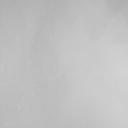
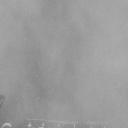
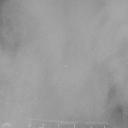
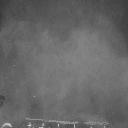
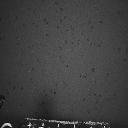
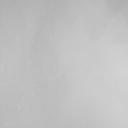
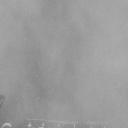
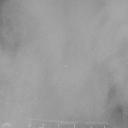
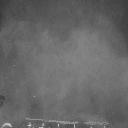

In [13]:
# See the output images
resample.images